# Cambridge Open Data — Health Analysis & Visualizations

This notebook loads dataset health metadata from SQLite and generates comprehensive visualizations for metadata quality analysis.

## Setup and Configuration

Import required libraries and configure visualization settings.

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

# Configure database path - find the project root by looking for the database directory
if os.path.exists("/Users/aasthagidwani/Desktop/dd4g-cambridge-meta-health/data/cambridge_metadata.db"):
    BASE_DIR = "/Users/aasthagidwani/Desktop/dd4g-cambridge-meta-health"
else:
    BASE_DIR = os.environ.get("BASE_DIR", os.path.dirname(os.path.abspath(__file__)))

DB_PATH = os.path.join(BASE_DIR, "data", "cambridge_metadata.db")

# Set style for better-looking charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Using database: {DB_PATH}")
print(f"Database exists: {os.path.exists(DB_PATH)}")

Using database: /Users/aasthagidwani/Desktop/dd4g-cambridge-meta-health/data/cambridge_metadata.db
Database exists: True


## Load Data from SQLite Database

Define function to connect to SQLite and retrieve health flags data filtered by LLM description score > 1.
The INNER JOIN ensures only datasets present in llm_results with a valid score are included.

In [5]:
def load_data():
    """Load health flags data from database with LLM filtering"""
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql("""
        SELECT h.* FROM health_flags h
        INNER JOIN llm_results l ON h.id = l.id
        WHERE l.llm_desc_score > 1
    """, conn)
    conn.close()
    return df

# Load the data
print("Loading data from database...")
df = load_data()
print(f"✓ Loaded {len(df)} datasets with LLM scores > 1\n")
print(f"Columns: {list(df.columns)}")

Loading data from database...
✓ Loaded 41 datasets with LLM scores > 1

Columns: ['id', 'missing_description', 'missing_tags', 'missing_license', 'missing_department', 'missing_category', 'is_stale', 'days_overdue', 'desc_score', 'tag_score', 'license_score', 'dept_score', 'category_score', 'freshness_score', 'health_score', 'health_band', 'scored_at']


## Health Score Distribution Visualization

Create a histogram showing the distribution of health scores across datasets.

✓ Saved: health_score_distribution.png


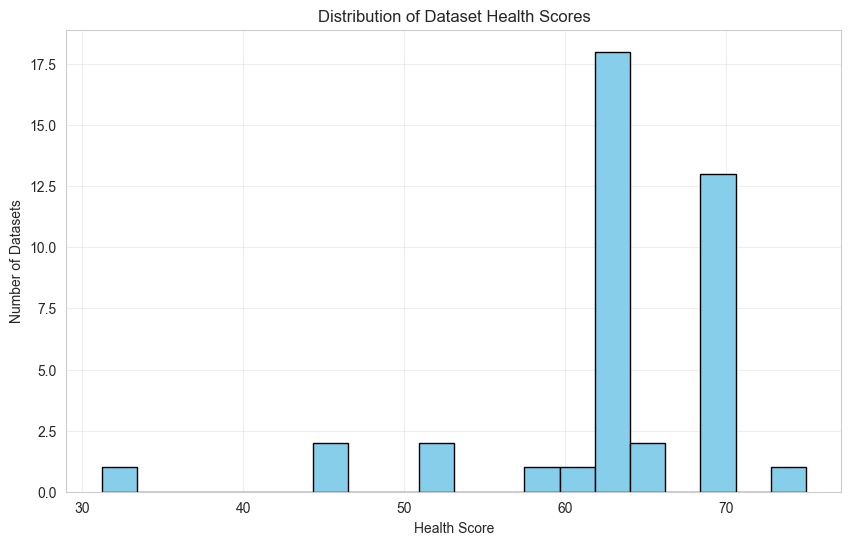

In [6]:
def visualization_health_distribution(df):
    """Chart 1: Distribution of health scores"""
    plt.figure(figsize=(10, 6))
    plt.hist(df['health_score'], bins=20, color='skyblue', edgecolor='black')
    plt.xlabel('Health Score')
    plt.ylabel('Number of Datasets')
    plt.title('Distribution of Dataset Health Scores')
    plt.grid(True, alpha=0.3)
    plt.savefig('health_score_distribution.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: health_score_distribution.png")
    plt.show()

visualization_health_distribution(df)

## Health Band Analysis Visualization

Generate a bar chart displaying dataset counts by health band (Good, Fair, Poor, Critical) with color coding and value labels.

✓ Saved: health_bands.png


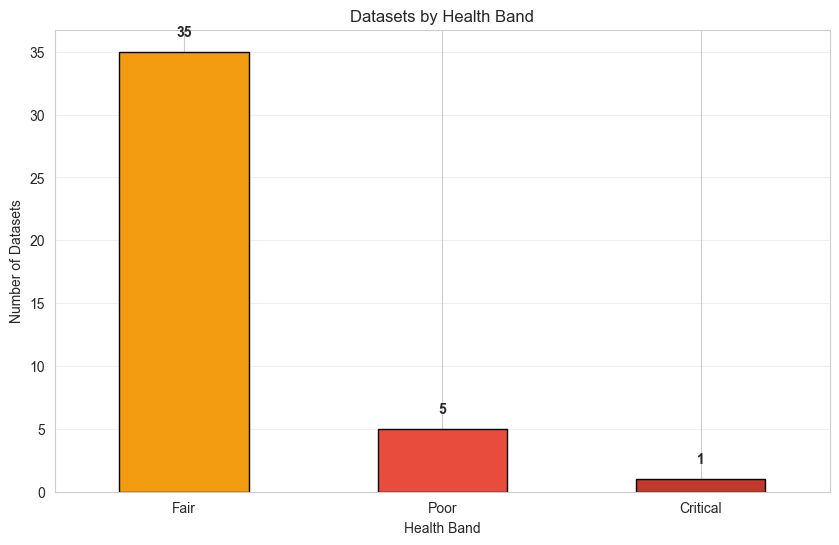

In [7]:
def visualization_health_bands(df):
    """Chart 2: Count of datasets by health band"""
    band_counts = df['health_band'].value_counts()
    colors = {'Good': '#2ECC71', 'Fair': '#F39C12', 'Poor': '#E74C3C', 'Critical': '#C0392B'}
    band_colors = [colors.get(band, '#95A5A6') for band in band_counts.index]

    plt.figure(figsize=(10, 6))
    band_counts.plot(kind='bar', color=band_colors, edgecolor='black')
    plt.xlabel('Health Band')
    plt.ylabel('Number of Datasets')
    plt.title('Datasets by Health Band')
    plt.xticks(rotation=0)
    plt.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for i, v in enumerate(band_counts):
        plt.text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')

    plt.savefig('health_bands.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: health_bands.png")
    plt.show()

visualization_health_bands(df)

## Missing Metadata Fields Visualization

Build a bar chart showing counts of missing metadata fields across all datasets.

✓ Saved: missing_fields.png


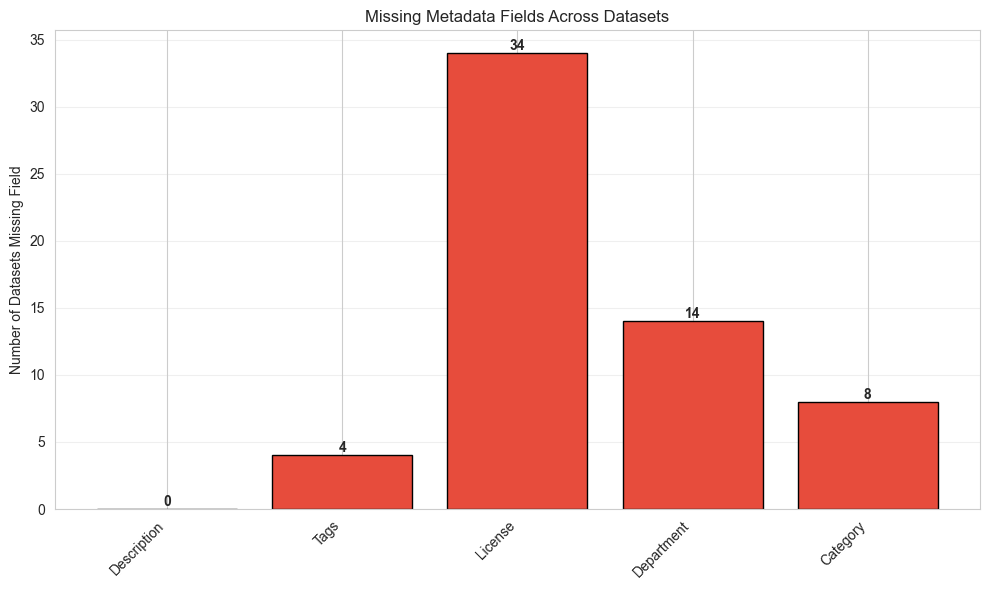

In [8]:
def visualization_missing_fields(df):
    """Chart 3: Missing fields breakdown"""
    missing_cols = ['missing_description', 'missing_tags', 'missing_license',
                    'missing_department', 'missing_category']
    missing_counts = [df[col].sum() for col in missing_cols]
    field_labels = ['Description', 'Tags', 'License', 'Department', 'Category']

    plt.figure(figsize=(10, 6))
    bars = plt.bar(field_labels, missing_counts, color='#E74C3C', edgecolor='black')
    plt.ylabel('Number of Datasets Missing Field')
    plt.title('Missing Metadata Fields Across Datasets')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig('missing_fields.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: missing_fields.png")
    plt.show()

visualization_missing_fields(df)

## Tags and License Score Visualization

Create a subplot figure with two charts: tag count distribution and license score distribution binned into ranges.

✓ Saved: tags_and_license.png


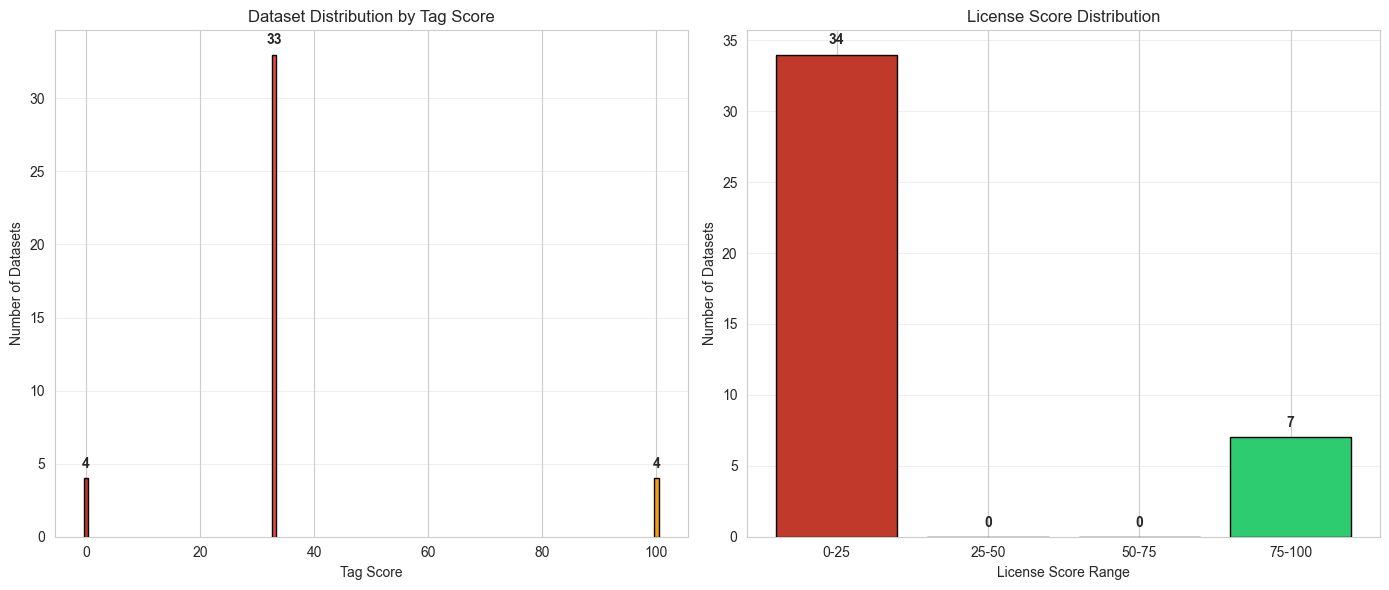

In [9]:
def visualization_tags_and_license(df):
    """Chart 4: Tag count distribution and License score"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Tags by score
    tag_counts = df['tag_score'].value_counts().sort_index()
    colors = ['#C0392B', '#E74C3C', '#F39C12', '#2ECC71']  # Red to Green

    ax1.bar(tag_counts.index, tag_counts.values, color=colors[:len(tag_counts)], edgecolor='black')
    ax1.set_xlabel('Tag Score')
    ax1.set_ylabel('Number of Datasets')
    ax1.set_title('Dataset Distribution by Tag Score')
    ax1.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for i, v in enumerate(tag_counts.values):
        ax1.text(tag_counts.index[i], v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

    # License scores
    license_bins = [0, 25, 50, 75, 100]
    license_labels = ['0-25', '25-50', '50-75', '75-100']
    df['license_bin'] = pd.cut(df['license_score'], bins=license_bins, labels=license_labels, include_lowest=True)
    license_dist = df['license_bin'].value_counts().sort_index()

    colors_license = ['#C0392B', '#E74C3C', '#F39C12', '#2ECC71']
    ax2.bar(range(len(license_dist)), license_dist.values, color=colors_license, edgecolor='black')
    ax2.set_xticks(range(len(license_dist)))
    ax2.set_xticklabels(license_dist.index)
    ax2.set_xlabel('License Score Range')
    ax2.set_ylabel('Number of Datasets')
    ax2.set_title('License Score Distribution')
    ax2.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for i, v in enumerate(license_dist.values):
        ax2.text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig('tags_and_license.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: tags_and_license.png")
    plt.show()

visualization_tags_and_license(df)

## Description Comparison: Original vs Suggested

Load datasets with original and AI-suggested descriptions to compare quality improvements.

In [13]:
def load_description_comparison():
    """Load original and suggested descriptions for comparison"""
    conn = sqlite3.connect(DB_PATH)
    df_comp = pd.read_sql("""
        SELECT 
            d.id, d.name, 
            d.description as original_description,
            l.llm_suggested_desc as suggested_description,
            l.llm_desc_score, l.llm_desc_feedback
        FROM datasets d
        INNER JOIN llm_results l ON d.id = l.id
        WHERE l.llm_suggested_desc IS NOT NULL
        ORDER BY l.llm_desc_score DESC
    """, conn)
    conn.close()
    return df_comp

df_comp = load_description_comparison()
print(f"✓ Loaded {len(df_comp)} datasets with suggested descriptions\n")

# Display basic statistics
print("Description Quality Scores:")
print(df_comp['llm_desc_score'].describe())
print(f"\nAverage Score: {df_comp['llm_desc_score'].mean():.2f}/5")

✓ Loaded 5 datasets with suggested descriptions

Description Quality Scores:
count    5.000000
mean     1.600000
std      0.547723
min      1.000000
25%      1.000000
50%      2.000000
75%      2.000000
max      2.000000
Name: llm_desc_score, dtype: float64

Average Score: 1.60/5


In [11]:
def compare_descriptions_side_by_side(df_comp, top_n=10):
    """Display side-by-side comparison of original vs suggested descriptions"""
    print(f"\n{'='*120}")
    print(f"TOP {top_n} DATASETS BY AI DESCRIPTION SCORE")
    print(f"{'='*120}\n")
    
    for idx, (_, row) in enumerate(df_comp.head(top_n).iterrows(), 1):
        print(f"#{idx} | {row['name'][:60]}")
        print(f"Score: {row['llm_desc_score']}/5")
        print(f"\n  📝 ORIGINAL DESCRIPTION:")
        original = row['original_description'] or "(empty)"
        print(f"     {original[:200]}{'...' if len(str(original)) > 200 else ''}")
        
        print(f"\n  ✨ AI SUGGESTED DESCRIPTION:")
        suggested = row['suggested_description'] or "(empty)"
        print(f"     {suggested[:200]}{'...' if len(str(suggested)) > 200 else ''}")
        
        if row['llm_desc_feedback']:
            print(f"\n  💬 AI FEEDBACK:")
            print(f"     {row['llm_desc_feedback']}")
        
        print(f"\n{'-'*120}\n")

compare_descriptions_side_by_side(df_comp, top_n=5)


TOP 5 DATASETS BY AI DESCRIPTION SCORE

#1 | DogLicenseInternal
Score: 2/5

  📝 ORIGINAL DESCRIPTION:
     Internal dataset to serve data to our dog license search app.

  ✨ AI SUGGESTED DESCRIPTION:
     This dataset, DogLicenseInternal, contains information on dog licenses, including pet details, owner information, and license status. It includes over 60 columns of data, primarily related to dog char...

  💬 AI FEEDBACK:
     Vague app purpose

------------------------------------------------------------------------------------------------------------------------

#2 | Chargepoint - aggregated data
Score: 2/5

  📝 ORIGINAL DESCRIPTION:
     Fleet and public charging data with added transforms for shiny app.
Do not make public.

  ✨ AI SUGGESTED DESCRIPTION:
     Fleet and public charging data with added transforms for an internal application. 

Note: The data is intended to be non-public.

  💬 AI FEEDBACK:
     Extremely vague

-------------------------------------------------------

✓ Saved: ai_description_scores.png


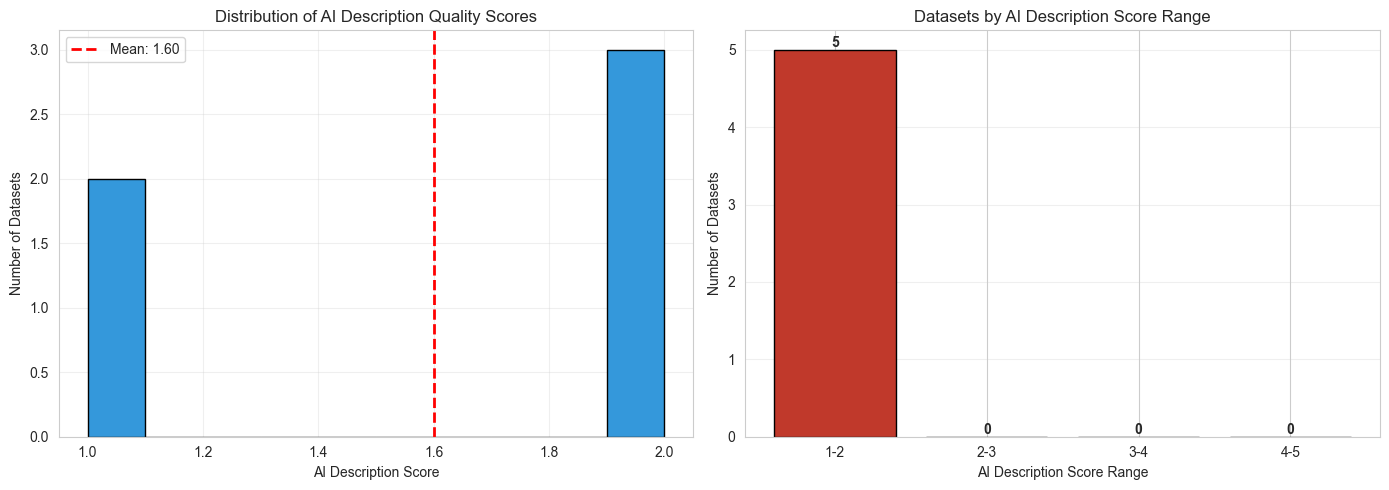

In [12]:
def visualization_description_scores(df_comp):
    """Visualize the distribution of AI description scores"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram of scores
    axes[0].hist(df_comp['llm_desc_score'], bins=10, color='#3498db', edgecolor='black')
    axes[0].axvline(df_comp['llm_desc_score'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_comp['llm_desc_score'].mean():.2f}")
    axes[0].set_xlabel('AI Description Score')
    axes[0].set_ylabel('Number of Datasets')
    axes[0].set_title('Distribution of AI Description Quality Scores')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Score breakdown - count by rating
    score_bins = [1, 2, 3, 4, 5]
    score_labels = ['1-2', '2-3', '3-4', '4-5']
    df_comp['score_bin'] = pd.cut(df_comp['llm_desc_score'], bins=score_bins, labels=score_labels, include_lowest=True)
    score_counts = df_comp['score_bin'].value_counts().sort_index()
    
    colors_score = ['#C0392B', '#E74C3C', '#F39C12', '#2ECC71']
    bars = axes[1].bar(range(len(score_counts)), score_counts.values, color=colors_score, edgecolor='black')
    axes[1].set_xticks(range(len(score_counts)))
    axes[1].set_xticklabels(score_counts.index)
    axes[1].set_xlabel('AI Description Score Range')
    axes[1].set_ylabel('Number of Datasets')
    axes[1].set_title('Datasets by AI Description Score Range')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('ai_description_scores.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: ai_description_scores.png")
    plt.show()

visualization_description_scores(df_comp)

## Summary and Data Export

View complete comparison data and export to CSV for further analysis.

## Description Quality Improvement Score

Calculate and visualize how much the AI-suggested descriptions improve upon the original descriptions.

In [ ]:
def calculate_description_metrics(description):
    """Calculate quality metrics for a description"""
    if not description or pd.isna(description):
        return {
            'length': 0,
            'word_count': 0,
            'char_density': 0,
            'has_content': False
        }
    
    text = str(description).strip()
    return {
        'length': len(text),
        'word_count': len(text.split()),
        'char_density': len(text.split()) / (len(text) + 1),  # Words per character
        'has_content': len(text) > 0
    }

# Calculate metrics for both original and suggested descriptions
print("Calculating description quality metrics...\n")

df_comp['original_metrics'] = df_comp['original_description'].apply(calculate_description_metrics)
df_comp['suggested_metrics'] = df_comp['suggested_description'].apply(calculate_description_metrics)

# Extract individual metrics
df_comp['original_length'] = df_comp['original_metrics'].apply(lambda x: x['length'])
df_comp['original_words'] = df_comp['original_metrics'].apply(lambda x: x['word_count'])
df_comp['suggested_length'] = df_comp['suggested_metrics'].apply(lambda x: x['length'])
df_comp['suggested_words'] = df_comp['suggested_metrics'].apply(lambda x: x['word_count'])

# Calculate improvement scores
# Quality improvement based on multiple factors:
# 1. Length improvement (better descriptions tend to be longer but not too long)
# 2. Word count improvement
# 3. AI description score (1-5)
# 4. Content completeness

df_comp['length_improvement'] = df_comp['suggested_length'] - df_comp['original_length']
df_comp['word_improvement'] = df_comp['suggested_words'] - df_comp['original_words']

# Overall improvement score (0-100)
# Factors: AI score (40%), length improvement (20%), word improvement (20%), completeness (20%)
df_comp['improvement_score'] = (
    (df_comp['llm_desc_score'] / 5 * 40) +  # AI quality score (0-40)
    (min(1, df_comp['length_improvement'] / 100) * 20) +  # Length improvement (0-20, normalized)
    (min(1, df_comp['word_improvement'] / 20) * 20) +  # Word improvement (0-20, normalized)
    (df_comp['suggested_metrics'].apply(lambda x: x['has_content']) * 20)  # Has content (0-20)
)

print(f"✓ Calculated metrics for {len(df_comp)} datasets\n")

# Display top improvements
print("="*100)
print("TOP IMPROVEMENTS: Original vs Suggested Descriptions")
print("="*100)

for idx, (_, row) in enumerate(df_comp.nlargest(5, 'improvement_score').iterrows(), 1):
    print(f"\n#{idx} | {row['name'][:60]}")
    print(f"Improvement Score: {row['improvement_score']:.1f}/100  |  AI Quality: {row['llm_desc_score']}/5")
    print(f"Length: {row['original_length']} → {row['suggested_length']} chars | Words: {row['original_words']} → {row['suggested_words']}")
    print(f"\n  Original ({row['original_length']} chars):")
    orig = row['original_description'] or "(empty)"
    print(f"    {str(orig)[:150]}{'...' if len(str(orig)) > 150 else ''}")
    print(f"\n  Suggested ({row['suggested_length']} chars):")
    sugg = row['suggested_description'] or "(empty)"
    print(f"    {str(sugg)[:150]}{'...' if len(str(sugg)) > 150 else ''}")
    print("-"*100)

In [ ]:
def visualize_improvement_scores(df_comp):
    """Create visualizations for improvement scores"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Overall Improvement Score Distribution
    axes[0, 0].hist(df_comp['improvement_score'], bins=10, color='#27AE60', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df_comp['improvement_score'].mean(), color='red', linestyle='--', linewidth=2, 
                       label=f"Mean: {df_comp['improvement_score'].mean():.1f}")
    axes[0, 0].set_xlabel('Improvement Score')
    axes[0, 0].set_ylabel('Number of Datasets')
    axes[0, 0].set_title('Distribution of Description Improvement Scores (0-100)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. AI Score vs Improvement Score scatter
    scatter = axes[0, 1].scatter(df_comp['llm_desc_score'], df_comp['improvement_score'], 
                                 s=100, c=df_comp['improvement_score'], cmap='RdYlGn', 
                                 edgecolors='black', alpha=0.6)
    axes[0, 1].set_xlabel('AI Description Quality Score (1-5)')
    axes[0, 1].set_ylabel('Overall Improvement Score')
    axes[0, 1].set_title('AI Quality Score vs Overall Improvement')
    axes[0, 1].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0, 1], label='Improvement Score')
    
    # 3. Length Improvement
    colors_improvement = ['#E74C3C' if x < 0 else '#2ECC71' for x in df_comp['length_improvement']]
    axes[1, 0].barh(range(len(df_comp)), df_comp['length_improvement'], color=colors_improvement, edgecolor='black')
    axes[1, 0].set_yticks(range(len(df_comp)))
    axes[1, 0].set_yticklabels([f"D{i+1}" for i in range(len(df_comp))], fontsize=8)
    axes[1, 0].set_xlabel('Character Length Change')
    axes[1, 0].set_title('Description Length Improvement (Negative = Shorter, Positive = Longer)')
    axes[1, 0].axvline(0, color='black', linestyle='-', linewidth=0.5)
    axes[1, 0].grid(True, alpha=0.3, axis='x')
    
    # 4. Word Count Improvement
    colors_words = ['#E74C3C' if x < 0 else '#2ECC71' for x in df_comp['word_improvement']]
    axes[1, 1].barh(range(len(df_comp)), df_comp['word_improvement'], color=colors_words, edgecolor='black')
    axes[1, 1].set_yticks(range(len(df_comp)))
    axes[1, 1].set_yticklabels([f"D{i+1}" for i in range(len(df_comp))], fontsize=8)
    axes[1, 1].set_xlabel('Word Count Change')
    axes[1, 1].set_title('Description Word Count Improvement')
    axes[1, 1].axvline(0, color='black', linestyle='-', linewidth=0.5)
    axes[1, 1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('description_improvement_analysis.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: description_improvement_analysis.png")
    plt.show()

visualize_improvement_scores(df_comp)

In [14]:
# Export comparison data to CSV
df_comp.to_csv('description_comparison.csv', index=False)
print("✓ Exported: description_comparison.csv\n")

# Summary statistics
print("="*80)
print("ANALYSIS SUMMARY")
print("="*80)
print(f"\nTotal Datasets with LLM Scores > 1: {len(df)}")
print(f"Datasets with Suggested Descriptions: {len(df_comp)}")
print(f"\nHealth Metrics:")
print(f"  • Avg Health Score: {df['health_score'].mean():.1f}")
print(f"  • Avg Description Score: {df['desc_score'].mean():.1f}")
print(f"  • Avg Tag Score: {df['tag_score'].mean():.1f}")
print(f"\nMissing Fields in Filtered Dataset:")
print(f"  • Missing Descriptions: {df['missing_description'].sum()}")
print(f"  • Missing Tags: {df['missing_tags'].sum()}")
print(f"  • Missing License: {df['missing_license'].sum()}")
print(f"\nAI Description Quality:")
print(f"  • Average Score: {df_comp['llm_desc_score'].mean():.2f}/5")
print(f"  • Min Score: {df_comp['llm_desc_score'].min():.2f}")
print(f"  • Max Score: {df_comp['llm_desc_score'].max():.2f}")
print(f"  • Median Score: {df_comp['llm_desc_score'].median():.2f}")
print("\n" + "="*80)
print("All visualizations and exports completed successfully! ✓")
print("="*80)

✓ Exported: description_comparison.csv

ANALYSIS SUMMARY

Total Datasets with LLM Scores > 1: 41
Datasets with Suggested Descriptions: 5

Health Metrics:
  • Avg Health Score: 63.1
  • Avg Description Score: 61.6
  • Avg Tag Score: 36.3

Missing Fields in Filtered Dataset:
  • Missing Descriptions: 0
  • Missing Tags: 4
  • Missing License: 34

AI Description Quality:
  • Average Score: 1.60/5
  • Min Score: 1.00
  • Max Score: 2.00
  • Median Score: 2.00

All visualizations and exports completed successfully! ✓
